**Import Libraries**

In [1]:
from libraries import*
from functions import fourier3, fourier5, fourier6, Rabc, Quad, ChemShift, AntiShift
from scipy.interpolate import make_interp_spline
import sympy as sym
from sympy import *
from matplotlib.lines import Line2D

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


In [2]:
w0 = 81.356 # larmor frequency for 17O
df = [0]*6
# Data for L-alanine
df[0] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/L_ala_all_site.xlsx', sheet_name='all_site_x', skiprows=[1])
df[1] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/L_ala_all_site.xlsx', sheet_name='all_site_y', skiprows=[1])
df[2] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/L_ala_all_site.xlsx', sheet_name='all_site_z', skiprows=[1])

# Data for D-alanine
df[3] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/D_ala_all_site.xlsx', sheet_name='all_site_x', skiprows=[1])
df[4] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/D_ala_all_site.xlsx', sheet_name='all_site_y', skiprows=[1])
df[5] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/D_ala_all_site.xlsx', sheet_name='all_site_z', skiprows=[1])




**For (-,-)8HQ**

In [28]:

L_alanine_x = [[14.737690, -3.367975, -1.051694, -4.514505, 4.254813], 
          [15.103190, -3.049508, 0.265975, -4.809242, 5.089568],
          [17.921716, 1.689737, 2.618147 ,8.682148 ,-2.390272],
          [11.365380 ,4.518315 ,-4.754899 ,1.772467 ,-5.416632],
          [18.570676 ,-1.186278 ,-4.394504 ,0.646455 ,-8.693795],
          [13.461091 ,9.159257 ,-2.221009 ,5.723060 ,-4.050988],
          [9.898037 ,-2.604969 ,1.996680 ,0.187430 ,0.391153],
          [8.949841 ,-2.688433 ,1.820286 ,0.332757 ,0.188034]] # coefficient from ASICS
# L_HQ_y = [[-2.630916, 2.462382, 0.271774, -0.401864, -0.525906], [-2.748530, 2.593289, 1.011176, -0.325788, -0.557786]] # coefficient from ASICS
# L_HQ_z = [[-3.468406, -1.138969, -0.574216, -0.939815, -1.094452], [-3.261651, -1.187894 ,-0.628636 ,-0.956962 ,-1.127200]] # coefficient from ASICS

# # Fit for Mounting 1

angle_smooth = np.linspace(df[0].angle.min(), df[0].angle.max(), 100) #100 points for smooth curve
L_alanine_1_x = fourier5(angle_smooth, *L_alanine_x[0])
L_alanine_2_x = fourier5(angle_smooth, *L_alanine_x[1])
L_alanine_3_x = fourier5(angle_smooth, *L_alanine_x[2])
L_alanine_4_x = fourier5(angle_smooth, *L_alanine_x[3])
L_alanine_5_x = fourier5(angle_smooth, *L_alanine_x[4])
L_alanine_6_x = fourier5(angle_smooth, *L_alanine_x[5])
L_alanine_7_x = fourier5(angle_smooth, *L_alanine_x[6])
L_alanine_8_x = fourier5(angle_smooth, *L_alanine_x[7])


# # Fit for Mounting 2
# L_HQ_1_y = fourier5(df[1].Angle, *L_HQ_y[0])
# L_HQ_2_y = fourier5(df[1].Angle, *L_HQ_y[1])

# # Fit for Mounting 3
# L_HQ_1_z = fourier5(df[2].Angle, *L_HQ_z[0])
# L_HQ_2_z = fourier5(df[2].Angle, *L_HQ_z[1])


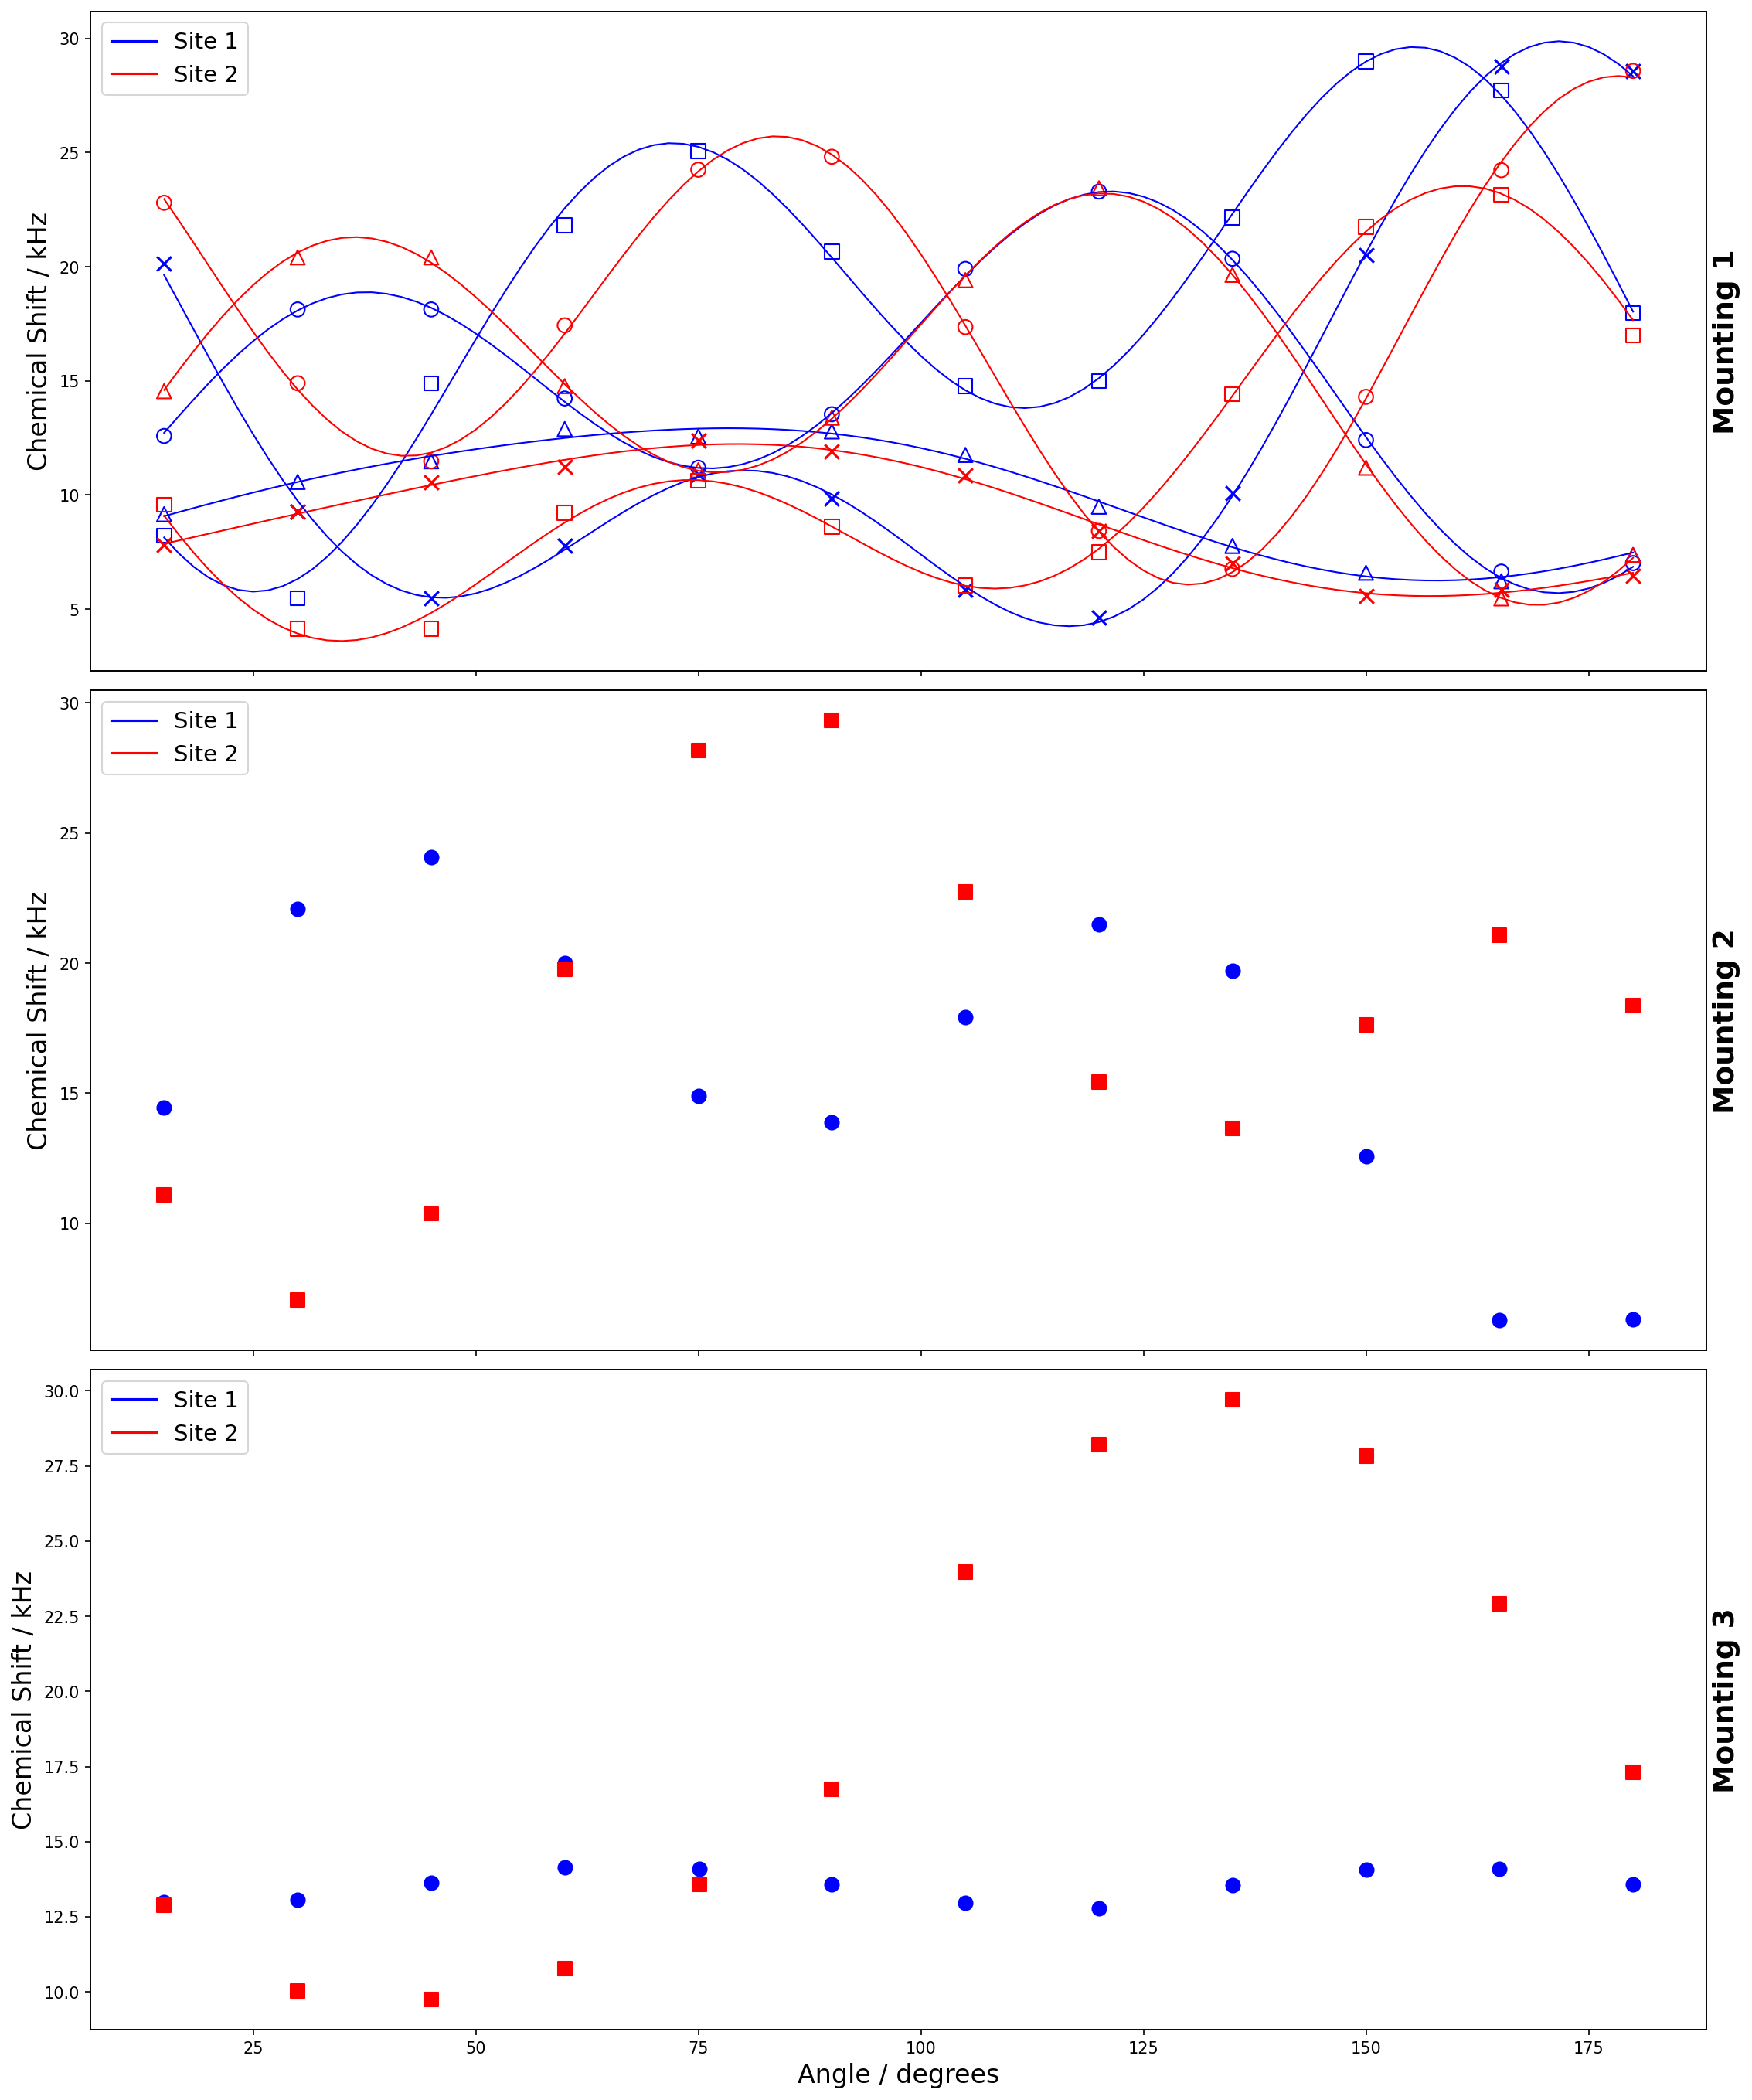

In [53]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Mount 1 data****************************
axes[0].scatter(df[0].angle, df[0].site1,  marker='o', s=80, facecolor='none', edgecolor='blue') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site2,  marker='s', s=80, facecolor='none', edgecolor='blue') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site3,  marker='^', s=80, facecolor='none', edgecolor='blue') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site4,  marker='x', s=80, c = 'blue') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site5,  marker='o', s=80, facecolor='none', edgecolor='r') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site6,  marker='s', s=80, facecolor='none', edgecolor='r') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site7,  marker='^', s=80, facecolor='none', edgecolor='r') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site8,  marker='x', s=80, c = 'r') #frequency in kHz


axes[0].plot(angle_smooth, L_alanine_1_x,  color='b', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_5_x,  color='b', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_6_x,  color='b', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_7_x,  color='b', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_2_x,  color='r', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_3_x,  color='r', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_4_x,  color='r', lw = 1) #Fit line


axes[0].plot(angle_smooth, L_alanine_8_x,  color='r', lw = 1) #Fit line



# Plot Mount 2 data****************************

axes[1].scatter(df[1].angle, df[1].site1,  marker='o', s=75, c = 'blue') #frequency in kHz

axes[1].scatter(df[1].angle, df[1].site2,  marker='s', s=75, c = 'red') #frequency in kHz

# axes[1].plot(df[1].Angle, L_HQ_1_y,  color='red', lw = 1)

# axes[1].plot(df[1].Angle, L_HQ_2_y,  color='blue', lw = 1)



# Plot Mount 3 data****************************

axes[2].scatter(df[2].angle, df[2].site1,  marker='o', s=75, c = 'blue') #frequency in kHz

axes[2].scatter(df[2].angle, df[2].site2,  marker='s', s=75, c = 'red') #frequency in kHz

# axes[2].plot(df[2].Angle, L_HQ_2_z,  color='red', lw = 1)

# axes[2].plot(df[2].Angle, L_HQ_1_z,  color='blue', lw = 1)

# Set x-axis label
plt.xlabel('Angle / degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[1].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[2].set_ylabel('Chemical Shift / kHz', fontsize=16)

# Right-side labels for Mount 1 , Mount 2, Mount 3 using twin axes
ax0_twin = axes[0].twinx()
ax0_twin.set_ylabel('Mounting 1', fontweight='bold', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel('Mounting 2', fontweight='bold', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel('Mounting 3', fontweight='bold', fontsize=18)
ax2_twin.yaxis.set_label_position("right")
ax2_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], color='b', label='Site 1'),
                 Line2D([0], [0], color='r',  label='Site 2'),
                 
                 ]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=1)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=1)
axes[2].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=1)
# ax0_twin.set_xlim(left=-10)
# Show the plot
plt.show()


In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster2Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster2Peak1,linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster2Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# Custom legend handle ( markers)
# marker_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
#                  Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
#                  Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan', markersize=8, label='Mounting 3')]

# Custom legend for lines
line_legend = [Line2D([0], [0], color='grey', lw=1, marker = 'o', linestyle='', markersize=8, markerfacecolor = 'blue',  label='Site 1'), 
               Line2D([0], [0], color='grey', lw=1,marker = '^', linestyle='', markersize=8, markerfacecolor = 'blue', label='Site 2')]

# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend =  line_legend
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=2)

# plt.title(r'Mounting 1 Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()


In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[1].Angle, df[1].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[2].Angle, df[2].Cluster1Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=3)



plt.title(r'$(-,-)8HQ(ipc)_2B$ Site 1 Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()


In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster2Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[1].Angle, df[1].Cluster2Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[2].Angle, df[2].Cluster2Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)



plt.title(r'$(-,-)8HQ(ipc)_2B$ Site 2 Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()

In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[1].Angle, df[1].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
plt.plot(df[1].Angle, df[1].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[2].Angle, df[2].Cluster1Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
plt.plot(df[2].Angle, df[2].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=8, label='Site 1'),
                 Line2D([0], [0], marker='^', color='w', markerfacecolor='grey', markersize=8, label='Site 2')]



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=2)



plt.title(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()


In [ ]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=2, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Site 1 data****************************
axes[0].plot(df[0].Angle, df[0].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')

axes[0].plot(df[1].Angle, df[1].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')

axes[0].plot(df[2].Angle, df[2].Cluster1Peak1, linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

# Plot Site 2 data****************************
axes[1].plot(df[0].Angle, df[0].Cluster2Peak1,linestyle='--', marker='s', color = 'grey', markersize=8, markerfacecolor = 'blue')

axes[1].plot(df[1].Angle, df[1].Cluster2Peak1,linestyle='--', marker='s', color = 'grey', markersize=8, markerfacecolor  = 'red')

axes[1].plot(df[2].Angle, df[2].Cluster2Peak1, linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

# Set x-axis label
plt.xlabel('Angle /degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift /ppm', fontsize=16)
axes[1].set_ylabel('Chemical Shift /ppm', fontsize=16)

# Right-side labels for Site 1 and Site 2 using twin axes
ax0_twin = axes[0].twinx()

ax0_twin.set_ylabel('Site 1', fontweight='bold', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel('Site 2', fontweight='bold', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
ax0_twin.set_xlim(left=-10)

# Save the plot to a specific folder
folder_path = '/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/NMR_analysis/plots_experiment/'  # Replace with the actual folder path
file_name = 'LHQ_site1_site2.png'
plt.savefig(folder_path + file_name, dpi=150, bbox_inches='tight')

# Show the plot
plt.show()


In [ ]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Mount 1 data****************************
axes[0].plot(df[0].Angle, df[0].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')

axes[0].plot(df[0].Angle, df[0].Cluster2Peak1,linestyle='--', marker='s', color = 'grey', markersize=8, markerfacecolor = 'blue')





# Plot Mount 2 data****************************

axes[1].plot(df[1].Angle, df[1].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')

axes[1].plot(df[1].Angle, df[1].Cluster2Peak1,linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor  = 'red')



# Plot Mount 2 data****************************

axes[2].plot(df[2].Angle, df[2].Cluster1Peak1, linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

axes[2].plot(df[2].Angle, df[2].Cluster2Peak1, linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

# Set x-axis label
plt.xlabel('Angle /degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift /ppm', fontsize=16)
axes[1].set_ylabel('Chemical Shift /ppm', fontsize=16)
axes[2].set_ylabel('Chemical Shift /ppm', fontsize=16)

# Right-side labels for Mount 1 , Mount 2, Mount 3 using twin axes
ax0_twin = axes[0].twinx()
ax0_twin.set_ylabel('Mounting 1', fontweight='bold', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel('Mounting 2', fontweight='bold', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel('Mounting 3', fontweight='bold', fontsize=18)
ax2_twin.yaxis.set_label_position("right")
ax2_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=8, label='Site 1'),
                 Line2D([0], [0], marker='^', color='w', markerfacecolor='black', markersize=8, label='Site 2'),
                 
                 ]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 0.06), ncol=23)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
axes[2].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
ax0_twin.set_xlim(left=-10)
# Show the plot
plt.show()


**For (+)8HQ**

In [27]:
D_HQ_x = [[-2.767572, -0.021837, -2.611411, 0.910820, 0.405120], [-0.902953 ,-1.814913, 0.661836, -0.373541, -0.493618]] # coefficient from ASICS
D_HQ_y = [[-3.845474 ,-0.065823 ,0.820338, 0.510270, 1.537412], [-2.045625, 0.688740, -1.907098, -0.481464, 0.489621]] # coefficient from ASICS
D_HQ_z = [[-1.865134 ,-1.927795 ,2.050566 ,0.604851, -0.045552], [-2.035060 ,-0.697897 ,0.778273 ,-0.288617 ,0.805603]] # coefficient from ASICS

# Fit for Mounting 1
D_HQ_1_x = fourier5(df[3].Angle, *D_HQ_x[0])
D_HQ_2_x = fourier5(df[3].Angle, *D_HQ_x[1])

# Fit for Mounting 2
D_HQ_1_y = fourier5(df[4].Angle, *D_HQ_y[0])
D_HQ_2_y = fourier5(df[4].Angle, *D_HQ_y[1])

# Fit for Mounting 3
D_HQ_1_z = fourier5(df[5].Angle, *D_HQ_z[0])
D_HQ_2_z = fourier5(df[5].Angle, *D_HQ_z[1])


In [ ]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Mount 1 data****************************
axes[0].scatter(df[3].Angle, df[3].Cluster1Peak1*w0/1000,  marker='o', s=75, c = 'blue') #frequency in kHz

axes[0].scatter(df[3].Angle, df[3].Cluster2Peak1*w0/1000,  marker='s', s=75, c = 'red') #frequency in kHz

axes[0].plot(df[3].Angle, D_HQ_2_x,  color='red', lw = 1)

axes[0].plot(df[3].Angle, D_HQ_1_x,  color='blue', lw = 1)



# Plot Mount 2 data****************************

axes[1].scatter(df[4].Angle, df[4].Cluster1Peak1*w0/1000,  marker='o', s=75, c = 'blue') #frequency in kHz

axes[1].scatter(df[4].Angle, df[4].Cluster2Peak1*w0/1000,  marker='s', s=75, c = 'red') #frequency in kHz

axes[1].plot(df[4].Angle, D_HQ_1_y,  color='red', lw = 1)

axes[1].plot(df[4].Angle, D_HQ_2_y,  color='blue', lw = 1)



# Plot Mount 3 data****************************

axes[2].scatter(df[5].Angle, df[5].Cluster1Peak1*w0/1000,  marker='o', s=75, c = 'blue') #frequency in kHz

axes[2].scatter(df[5].Angle, df[5].Cluster2Peak1*w0/1000,  marker='s', s=75, c = 'red') #frequency in kHz

axes[2].plot(df[5].Angle, D_HQ_1_z,  color='red', lw = 1)

axes[2].plot(df[5].Angle, D_HQ_2_z,  color='blue', lw = 1)

# Set x-axis label
plt.xlabel('Angle / degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[1].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[2].set_ylabel('Chemical Shift / kHz', fontsize=16)

# Right-side labels for Mount 1 , Mount 2, Mount 3 using twin axes
ax0_twin = axes[0].twinx()
ax0_twin.set_ylabel('Mounting 1', fontweight='bold', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel('Mounting 2', fontweight='bold', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel('Mounting 3', fontweight='bold', fontsize=18)
ax2_twin.yaxis.set_label_position("right")
ax2_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',  markersize=12, label='Site 1'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='r', markersize=12, label='Site 2'),
                 
                 ]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=1)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=1)
axes[2].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=1)
ax0_twin.set_xlim(left=-10)
# Show the plot
plt.show()


In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[3].Angle, df[3].Cluster2Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[4].Angle, df[4].Cluster2Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[5].Angle, df[5].Cluster2Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=3)



plt.title(r'$(+,+)8HQ(ipc)_2B$ Site 2 Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()

In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[3].Angle, df[3].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[4].Angle, df[4].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[5].Angle, df[5].Cluster1Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=3)



plt.title(r'$(+,+)8HQ(ipc)_2B$ Site 1 Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()


In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[3].Angle, df[3].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
plt.plot(df[3].Angle, df[3].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[4].Angle, df[4].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
plt.plot(df[4].Angle, df[4].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[5].Angle, df[5].Cluster1Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
plt.plot(df[5].Angle, df[5].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=8, label='Site 1'),
                 Line2D([0], [0], marker='^', color='w', markerfacecolor='grey', markersize=8, label='Site 2')]



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=2)



plt.title(r'$(+,+)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()

In [ ]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=2, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(+,+)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Site 1 data****************************
axes[0].plot(df[3].Angle, df[3].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')

axes[0].plot(df[4].Angle, df[4].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')

axes[0].plot(df[5].Angle, df[5].Cluster1Peak1, linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

# Plot Site 2 data****************************
axes[1].plot(df[3].Angle, df[3].Cluster2Peak1,linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor = 'blue')

axes[1].plot(df[4].Angle, df[4].Cluster2Peak1,linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor  = 'red')

axes[1].plot(df[5].Angle, df[5].Cluster2Peak1, linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

# Set x-axis label
plt.xlabel('Angle /degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift /ppm', fontsize=16)
axes[1].set_ylabel('Chemical Shift /ppm', fontsize=16)

# Right-side labels for Site 1 and Site 2 using twin axes
ax0_twin = axes[0].twinx()

ax0_twin.set_ylabel('Site 1', fontweight='bold', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel('Site 2', fontweight='bold', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
ax0_twin.set_xlim(left=-5) # start x-axes from 0


# Save the plot to a specific folder
folder_path = '/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/NMR_analysis/plots_experiment/'  # Replace with the actual folder path
file_name = 'DHQ_site1_site2.png'
plt.savefig(folder_path + file_name, dpi=150, bbox_inches='tight')

# Show the plot
plt.show()
